In [1]:
library(tidyverse)
library(lubridate)
library(broom)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
jembe     <- read_csv("jembe.csv")     %>% mutate(facility = "Jembe CHC")
ngelehun  <- read_csv("Ngelehun.csv")  %>% mutate(facility = "Ngelehun CHC")


Rows: 24 Columns: 34
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): periodname
dbl (16): periodid, periodcode, All other referrals, Anaemia referrals, Burn...
lgl (17): perioddescription, Acute Flaccid Paralysis (AFP) referrals, Diarrh...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 24 Columns: 34
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): periodname
dbl (30): periodid, periodcode, Acute Flaccid Paralysis (AFP) referrals, All...
lgl  (3): perioddescription, PLHIVs referred for TB screening, PLHIVs referr...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
df <- bind_rows(jembe, ngelehun)

In [5]:
df <- df %>%
  mutate(
    periodcode = as.character(periodcode),
    date       = as.Date(paste0(periodcode, "01"), format = "%Y%m%d"),
    time_index = dense_rank(date)      # 1,2,3… in chronological order
  ) %>%
  arrange(facility, date)

In [6]:
non_ref_cols <- c("periodid", "periodname", "periodcode",
                  "perioddescription", "facility", "date", "time_index")

# indicator columns (all numeric, excluding ids)
referral_cols <- df %>%
  select(-all_of(non_ref_cols)) %>%
  select(where(is.numeric)) %>%
  colnames()

length(referral_cols)

[1] 30

In [7]:
df <- df %>%
  rowwise() %>%
  mutate(
    total_referrals = sum(c_across(all_of(referral_cols)), na.rm = TRUE)
  ) %>%
  ungroup()


In [8]:
completeness_summary <- df %>%
  group_by(facility) %>%
  summarise(
    first_month = min(date),
    last_month  = max(date),
    n_months    = n()
  )

print(completeness_summary)


# A tibble: 2 × 4
  facility     first_month last_month n_months
  <chr>        <date>      <date>        <int>
1 Jembe CHC    2024-01-01  2025-12-01       24
2 Ngelehun CHC 2024-01-01  2025-12-01       24


In [10]:
missing_by_month <- df %>%
  rowwise() %>%
  mutate(
    n_na_indicators = sum(is.na(c_across(all_of(referral_cols))))
  ) %>%
  ungroup() %>%
  select(facility, date, total_referrals, n_na_indicators)

print(missing_by_month,n=Inf)


# A tibble: 48 × 4
   facility     date       total_referrals n_na_indicators
   <chr>        <date>               <dbl>           <int>
 1 Jembe CHC    2024-01-01              26              21
 2 Jembe CHC    2024-02-01              48              22
 3 Jembe CHC    2024-03-01              64              24
 4 Jembe CHC    2024-04-01              43              23
 5 Jembe CHC    2024-05-01              42              23
 6 Jembe CHC    2024-06-01              71              24
 7 Jembe CHC    2024-07-01              82              25
 8 Jembe CHC    2024-08-01              55              22
 9 Jembe CHC    2024-09-01              79              26
10 Jembe CHC    2024-10-01              46              25
11 Jembe CHC    2024-11-01              49              26
12 Jembe CHC    2024-12-01              42              25
13 Jembe CHC    2025-01-01              26              21
14 Jembe CHC    2025-02-01              48              22
15 Jembe CHC    2025-03-01           

In [14]:
outliers <- df %>%
  group_by(facility) %>%
  mutate(
    mean_ref  = mean(total_referrals, na.rm = TRUE),
    sd_ref    = sd(total_referrals,  na.rm = TRUE),
    z_score   = ifelse(sd_ref > 0,
                       (total_referrals - mean_ref) / sd_ref,
                       NA_real_),
    outlier   = abs(z_score) >= 2   # flag >= 2 SD from mean
  ) %>%
  ungroup() %>%
  filter(outlier)

print(outliers,n = Inf)

# A tibble: 2 × 42
  periodid periodname   periodcode perioddescription Acute Flaccid Paralysis (…¹
     <dbl> <chr>        <chr>      <lgl>                                   <dbl>
1   202401 January 2024 202401     NA                                          1
2   202501 January 2025 202501     NA                                          1
# ℹ abbreviated name: ¹​`Acute Flaccid Paralysis (AFP) referrals`
# ℹ 37 more variables: `All other referrals` <dbl>, `Anaemia referrals` <dbl>,
#   `Burns referrals` <dbl>, `Clinical Malnutrition referrals` <dbl>,
#   `Diarrhoea with blood (Dysentery) referrals` <dbl>,
#   `Diarrhoea with severe dehydration referrals` <dbl>,
#   `Eye infection referrals` <dbl>, `Hypertension referrals` <dbl>,
#   `Lassa fever referrals` <dbl>, `Leprosy referrals` <dbl>, …


In [15]:
descriptive_stats <- df %>%
  group_by(facility) %>%
  summarise(
    mean_referrals = mean(total_referrals, na.rm = TRUE),
    sd_referrals   = sd(total_referrals,   na.rm = TRUE),
    min_referrals  = min(total_referrals,  na.rm = TRUE),
    max_referrals  = max(total_referrals,  na.rm = TRUE),
    cv_referrals   = sd_referrals / mean_referrals * 100   # coefficient of variation
  )

print(descriptive_stats)

# A tibble: 2 × 6
  facility  mean_referrals sd_referrals min_referrals max_referrals cv_referrals
  <chr>              <dbl>        <dbl>         <dbl>         <dbl>        <dbl>
1 Jembe CHC           53.9         16.5            26            82         30.5
2 Ngelehun…           16.1         32.9             0           117        205. 


In [17]:
df_changes <- df %>%
  arrange(facility, date) %>%
  group_by(facility) %>%
  mutate(
    lag_total   = lag(total_referrals),
    pct_change  = (total_referrals - lag_total) / lag_total * 100
  ) %>%
  ungroup()

 df_changes %>%
  select(facility, date, total_referrals, pct_change) %>%
  print(n = Inf, width = Inf)



# A tibble: 48 × 4
   facility     date       total_referrals pct_change
   <chr>        <date>               <dbl>      <dbl>
 1 Jembe CHC    2024-01-01              26      NA   
 2 Jembe CHC    2024-02-01              48      84.6 
 3 Jembe CHC    2024-03-01              64      33.3 
 4 Jembe CHC    2024-04-01              43     -32.8 
 5 Jembe CHC    2024-05-01              42      -2.33
 6 Jembe CHC    2024-06-01              71      69.0 
 7 Jembe CHC    2024-07-01              82      15.5 
 8 Jembe CHC    2024-08-01              55     -32.9 
 9 Jembe CHC    2024-09-01              79      43.6 
10 Jembe CHC    2024-10-01              46     -41.8 
11 Jembe CHC    2024-11-01              49       6.52
12 Jembe CHC    2024-12-01              42     -14.3 
13 Jembe CHC    2025-01-01              26     -38.1 
14 Jembe CHC    2025-02-01              48      84.6 
15 Jembe CHC    2025-03-01              43     -10.4 
16 Jembe CHC    2025-04-01              64      48.8 
17 Jembe 

In [19]:
cause_totals <- df %>%
  group_by(facility) %>%
  summarise(across(all_of(referral_cols), ~ sum(.x, na.rm = TRUE))) %>%
  pivot_longer(cols = all_of(referral_cols),
               names_to = "cause",
               values_to = "referrals") %>%
  group_by(facility) %>%
  mutate(
    total_facility = sum(referrals),
    pct_of_total   = 100 * referrals / total_facility
  ) %>%
  arrange(facility, desc(referrals))

print(cause_totals,n=Inf)

# A tibble: 60 × 5
# Groups:   facility [2]
   facility     cause                      referrals total_facility pct_of_total
   <chr>        <chr>                          <dbl>          <dbl>        <dbl>
 1 Jembe CHC    Malaria referrals                562           1294       43.4  
 2 Jembe CHC    Anaemia referrals                382           1294       29.5  
 3 Jembe CHC    All other referrals              146           1294       11.3  
 4 Jembe CHC    Clinical Malnutrition ref…        74           1294        5.72 
 5 Jembe CHC    Burns referrals                   20           1294        1.55 
 6 Jembe CHC    Worm infestation referrals        20           1294        1.55 
 7 Jembe CHC    Wounds/Trauma referrals           18           1294        1.39 
 8 Jembe CHC    Measles referrals                 16           1294        1.24 
 9 Jembe CHC    Eye infection referrals           12           1294        0.927
10 Jembe CHC    PLHIVs referred for TB sc…        10           12

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


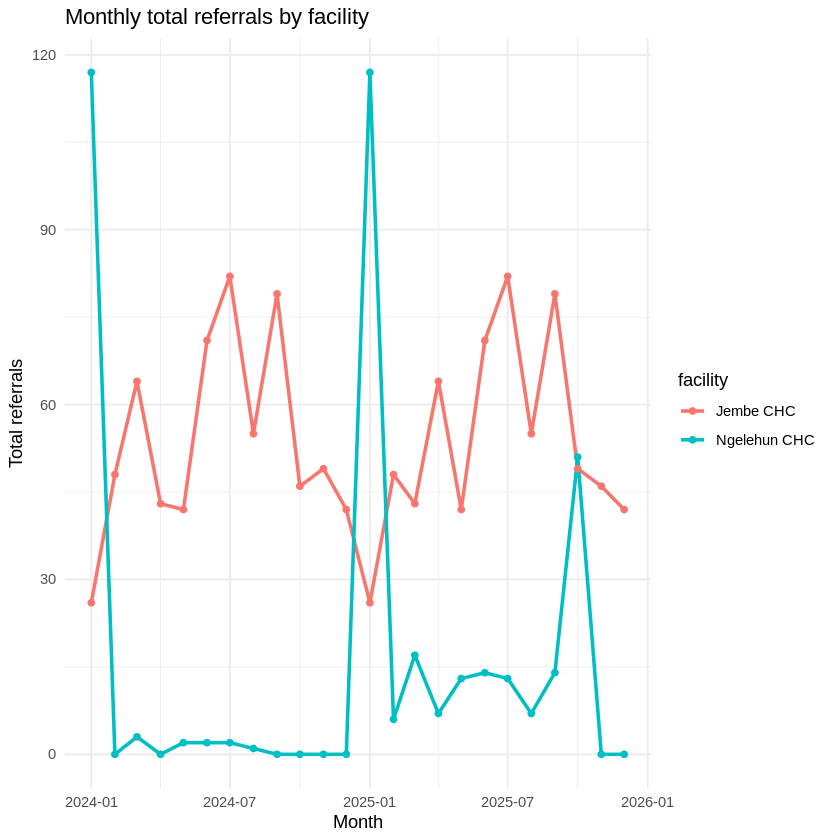

In [20]:
ggplot(df, aes(x = date, y = total_referrals, colour = facility)) +
  geom_line(size = 1) +
  geom_point() +
  labs(title = "Monthly total referrals by facility",
       x = "Month", y = "Total referrals") +
  theme_minimal()

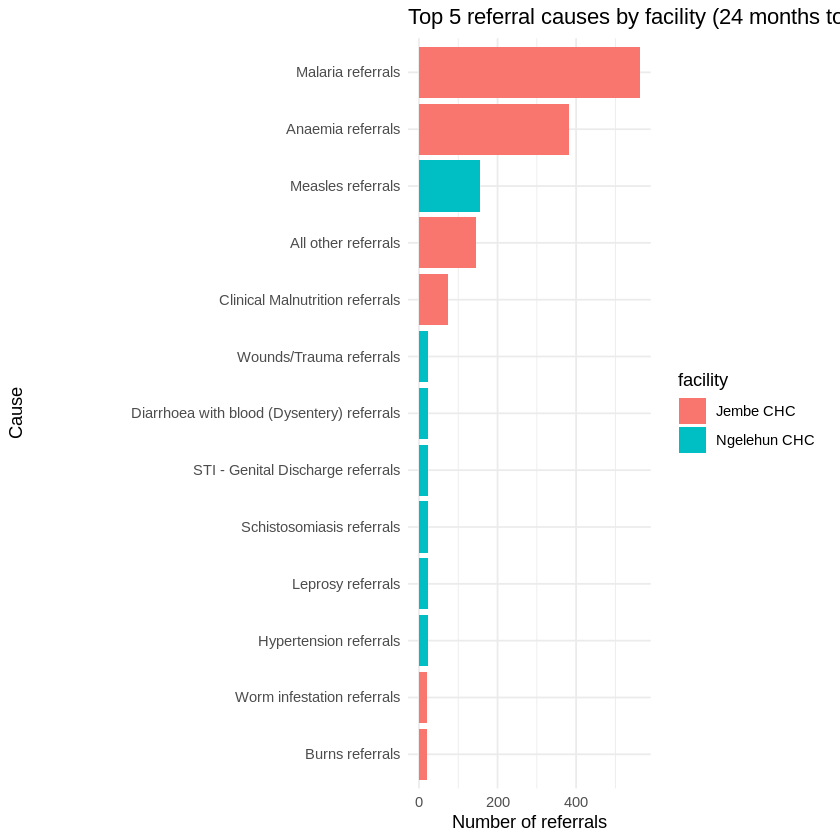

In [21]:
top5_causes <- cause_totals %>%
  group_by(facility) %>%
  slice_max(order_by = referrals, n = 5)

ggplot(top5_causes,
       aes(x = reorder(cause, referrals), y = referrals, fill = facility)) +
  geom_col(position = "dodge") +
  coord_flip() +
  labs(title = "Top 5 referral causes by facility (24 months total)",
       x = "Cause", y = "Number of referrals") +
  theme_minimal()

In [22]:
trend_results <- df %>%
  group_by(facility) %>%
  group_modify(~ {
    m <- lm(total_referrals ~ time_index, data = .x)
    tibble(
      slope      = coef(m)[["time_index"]],
      p_value    = summary(m)$coefficients["time_index", "Pr(>|t|)"],
      r_squared  = summary(m)$r.squared
    )
  })

print(trend_results)


# A tibble: 2 × 4
# Groups:   facility [2]
  facility      slope p_value r_squared
  <chr>         <dbl>   <dbl>     <dbl>
1 Jembe CHC     0.267   0.594   0.0131 
2 Ngelehun CHC -0.354   0.724   0.00577


In [23]:
wide_fac <- df %>%
  select(facility, date, total_referrals) %>%
  pivot_wider(names_from = facility, values_from = total_referrals)

cor_result <- cor(wide_fac$`Jembe CHC`,
                  wide_fac$`Ngelehun CHC`,
                  use = "complete.obs")

cor_result

[1] -0.4833755

In [25]:
seasonality <- df %>%
  mutate(month = month(date, label = TRUE, abbr = TRUE)) %>%
  group_by(facility, month) %>%
  summarise(
    mean_referrals = mean(total_referrals, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(facility, month)

print(seasonality,n = Inf)


# A tibble: 24 × 3
   facility     month mean_referrals
   <chr>        <ord>          <dbl>
 1 Jembe CHC    Jan             26  
 2 Jembe CHC    Feb             48  
 3 Jembe CHC    Mar             53.5
 4 Jembe CHC    Apr             53.5
 5 Jembe CHC    May             42  
 6 Jembe CHC    Jun             71  
 7 Jembe CHC    Jul             82  
 8 Jembe CHC    Aug             55  
 9 Jembe CHC    Sep             79  
10 Jembe CHC    Oct             47.5
11 Jembe CHC    Nov             47.5
12 Jembe CHC    Dec             42  
13 Ngelehun CHC Jan            117  
14 Ngelehun CHC Feb              3  
15 Ngelehun CHC Mar             10  
16 Ngelehun CHC Apr              3.5
17 Ngelehun CHC May              7.5
18 Ngelehun CHC Jun              8  
19 Ngelehun CHC Jul              7.5
20 Ngelehun CHC Aug              4  
21 Ngelehun CHC Sep              7  
22 Ngelehun CHC Oct             25.5
23 Ngelehun CHC Nov              0  
24 Ngelehun CHC Dec              0  


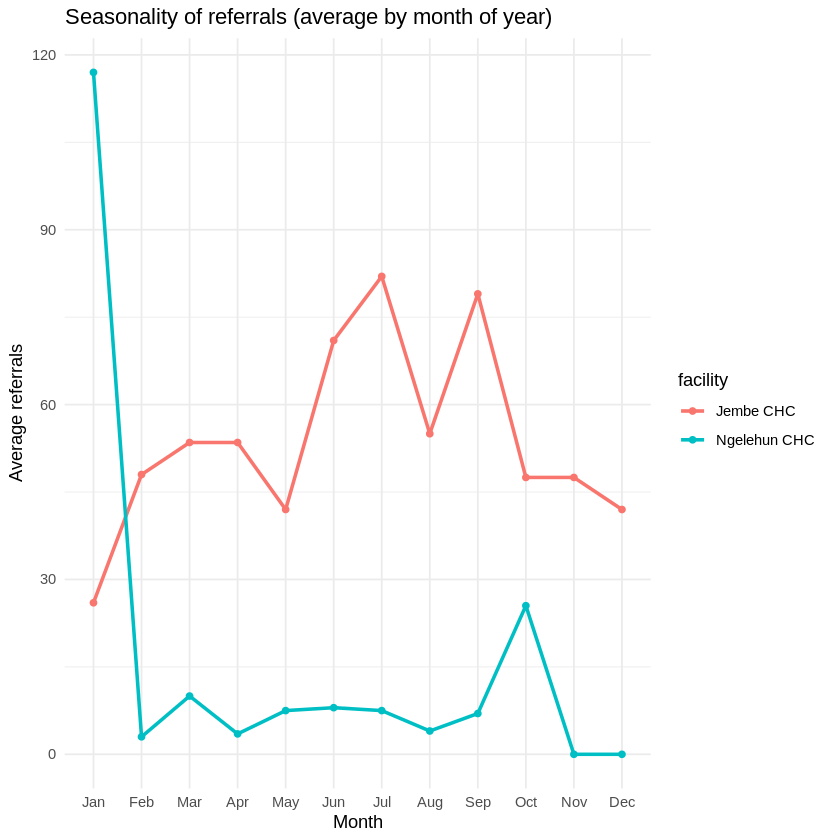

In [26]:
ggplot(seasonality,
       aes(x = month, y = mean_referrals, group = facility, colour = facility)) +
  geom_line(size = 1) +
  geom_point() +
  labs(title = "Seasonality of referrals (average by month of year)",
       x = "Month", y = "Average referrals") +
  theme_minimal()

In [27]:
write_csv(descriptive_stats, "descriptive_stats_by_facility.csv")
write_csv(outliers,          "outlier_months.csv")
write_csv(cause_totals,      "cause_totals_by_facility.csv")
write_csv(df_changes,        "month_to_month_changes.csv")
write_csv(seasonality,       "seasonality_summary.csv")